In [1]:
import matplotlib.pyplot as plt

In [2]:
# Check what thefuzz is actually using
from thefuzz import fuzz as thefuzz_fuzz
print(thefuzz_fuzz.partial_ratio.__module__)  # Should show rapidfuzz if installed
from fuzzywuzzy import fuzz as fuzzywuzzy_fuzz
# Compare speeds
import time
from thefuzz import fuzz as tf
from rapidfuzz import fuzz as rf
from fuzzywuzzy import fuzz as fw


thefuzz.fuzz


In [3]:
rapidfuzztime = []
thefuzztime = []

In [4]:
fuzzywuzzytime = []

In [5]:
for fac in [50, 100, 150, 200, 250, 300, 500, 1000]:
    print(fac)
    t1 = "hello world " * fac
    t2 = "hello earth " * fac
    # rapidfuzz
    start = time.time()
    for _ in range(5):
        fw.partial_ratio(t1, t2)
    print(f"fuzzywuzzytime: {time.time() - start:.2f}s")
    fuzzywuzzytime.append(time.time() - start)
    

50
fuzzywuzzytime: 0.01s
100
fuzzywuzzytime: 0.03s
150
fuzzywuzzytime: 0.10s
200


fuzzywuzzytime: 0.23s
250


fuzzywuzzytime: 0.44s
300


fuzzywuzzytime: 0.78s
500


fuzzywuzzytime: 3.65s
1000


fuzzywuzzytime: 30.14s


In [6]:
for fac in [50, 100, 150, 200, 250, 300, 500, 1000]:
    print(fac)
    t1 = "hello world " * fac
    t2 = "hello earth " * fac
    # rapidfuzz
    start = time.time()
    for _ in range(5):
        rf.partial_ratio(t1, t2)
    print(f"rapidfuzz: {time.time() - start:.2f}s")
    rapidfuzztime.append(time.time() - start)
    
    # thefuzz
    start = time.time()
    for _ in range(5):
        tf.partial_ratio(t1, t2)
    print(f"thefuzz: {time.time() - start:.2f}s")
    thefuzztime.append(time.time() - start)

50
rapidfuzz: 0.04s
thefuzz: 0.04s
100
rapidfuzz: 0.21s


thefuzz: 0.21s
150


rapidfuzz: 0.76s


thefuzz: 0.76s
200


rapidfuzz: 1.83s

...

rapidfuzz: 6.64s


thefuzz: 6.50s


500
rapidfuzz: 32.22s
thefuzz: 31.25s
1000


rapidfuzz: 262.57s


thefuzz: 261.89s


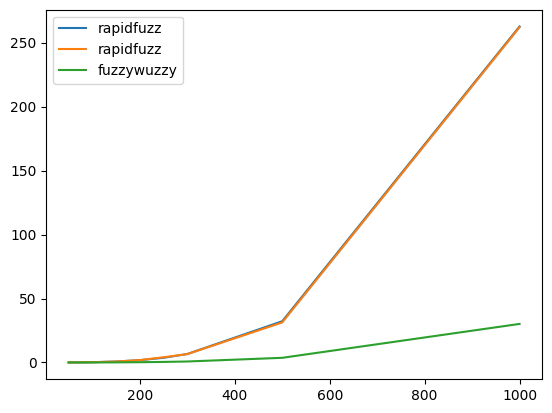

In [7]:
plt.plot([50, 100, 150, 200, 250, 300, 500, 1000], rapidfuzztime, label ="rapidfuzz")
plt.plot([50, 100, 150, 200, 250, 300, 500, 1000], thefuzztime, label ="rapidfuzz")
plt.plot([50, 100, 150, 200, 250, 300, 500, 1000], fuzzywuzzytime, label ="fuzzywuzzy")
plt.legend()

In [15]:
import os
print(f"CPU count: {os.cpu_count()}") 

CPU count: 8


In [22]:
print(rapidfuzztime)
print(thefuzztime)
print(fuzzywuzzytime)

[0.0358579158782959, 0.1902320384979248, 0.6823551654815674, 1.7161381244659424, 3.467738151550293, 6.256356954574585, 31.27255082130432, 259.8272898197174]
[0.0344691276550293, 0.18785595893859863, 0.6816577911376953, 1.7227699756622314, 3.4788658618927, 6.252071857452393, 31.392539978027344, 260.1992609500885]
[0.00819706916809082, 0.028536081314086914, 0.08777093887329102, 0.2107231616973877, 0.4205770492553711, 0.7453339099884033, 3.6143639087677, 30.174036026000977]
